<a href="https://colab.research.google.com/github/diegofranco22df-alt/Analisis-ConnectaTel/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

El objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Se trabajará con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello se trabajará con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Voy a **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.



---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarze con la estructura de los tres datasets**.  
En esta etapa, se validará que los archivos se carguen correctamente, conocer sus columnas y tipos de datos, y detectar posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

- Importar las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Cargar los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guardar los DataFrames en las variables: `plans`, `users`, `usage`.  
- Mostrar las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.


In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.


In [ ]:
# cantidad de nulos para users
print( "Cantidad de valores nulos:")
print(users.isna().sum())
print()
print( "Proporción de valores nulos:")
print(users.isna().mean())

Cantidad de valores nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print("Cantidad de valores nulos:")
print(usage.isna().sum())
print()
print("Proporción de valores nulos:")
print(usage.isna().mean())

Cantidad de valores nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- En el database Users, la columna 'city' tiene 469 valores nulos con una proporción de 0.11, la columna 'churn _date' tiene 3.534 valores nulos con una proporción de 0.88
- En el database Usage, la columna 'date' tiene 50 valores nulos con una proporción de 0.001, 'duration' tiene 22.076 valores nulos con proporción 0.55, 'lenght' tiene 17.896 valores nulos con proporción de 0.44
- Imputaría las columnas 'city', 'date', 'duration', 'lenght' dado que son rangos importantes para el análisis, y las proporciones de valores nulos no es tan alta.
- Ignoraría la columna 'churn_date' ya que la proporción de 0.88 es muy alta.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` tiene 4000 filas o registros, la media y la mediana están iguales, sin embargo considero que esta columna no es relevante para el análisis.
- La columna `age` tiene 4000 registros, la media y la mediana están alejadas, lo que indica sesgo en los datos, el min -999 es un outlier que se debe imputar.

In [ ]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` tienen 40000 registros cada una, son datos de identificación, poco relevantes para el análisis.
- La columna `duration` tiene baja dispersión de los datos con 6.84, la media y la mediana están algo dispersas, los datos están sesgados a la derecha.
- La columna `lenght` también tiene sesgo de los datos a la derecha.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for columna in columnas_user:
    print(f"\n{columna.upper()}")
    print(users[columna].value_counts())


CITY
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

PLAN
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` tiene 6 ciudades únicas, y un sentinel (?).
- La columna `plan` tiene 2 valores únicos, básico y premium.

In [ ]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` tiene 2 valores únicos, el valor top es text con 22.092 de 40.000 registros.


**Valores inválidos o sentinels**  
- En la columna `age` del database users encontré el sentinel -999.00
- En la columna `city` del database users hay 96 registros con el sentinel "?"
- Para la columna `age` imputaría los sentinels con la mediana.
- Para la columna `city` para los valores "?" los reemplazaría por valores nulos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])

In [ ]:
# Revisar los años presentes en `reg_date` de users
unique_years_users= users['reg_date'].dt.year.unique()
print("Años presentes en users:", unique_years_users)
print()
print("Value counts:")
users['reg_date'].dt.year.value_counts()

Años presentes en users: [2022 2026 2023 2024]

Value counts:


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, están presentes los años 2022, 2023, 2024 y 2026.

In [ ]:
# Revisar los años presentes en `date` de usage
unique_years_usage= usage['date'].dt.year.unique()
print("Años presentes en usage:", unique_years_usage)
print()
print("Value_counts:")
usage['date'].dt.year.value_counts()

Años presentes en usage: [2024.   nan]

Value_counts:


2024.0    39950
Name: date, dtype: int64

En `date`, está presente el año 2024 y 50 datos con valores nulos.

Basaremos el análisis en estas fechas.

**Fechas fuera de rango**  
- Aparecen 40 registros del año 2026 en la columna `reg_date`, año que no ha transcurrido.
- Aparecen 50 datos nulos en la columna `date`
- Las fechas fueras de rango al tener una proporción baja las marcaría como nulas.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.


In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city']= users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts()

2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.


In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Luego de ejecutar los códigos se evidencia que no son MAR, siguen un patrón sistemático, dado que:

Para `duration` el 0% de call tienen valores faltantes, y el 99.93% de text tienen valores faltantes.

Para `length` el 0% de text tienen valores faltantes, y el 99.93% de call tienen valores faltantes.

Esto es lógico ya que todas las llamadas deben tener una duración en tiempo, y todos los mensajes deben tener una longitud de texto.
Se confirma que las columnas `duration` y `length` dependen de la columna `type`, y no son valores faltantes al azar.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.


In [ ]:
# Columnas auxiliares
#conocer el total de mensajes
usage["is_text"] = (usage["type"] == "text").astype(int)
#conocer el total de llamadas
usage["is_call"] = (usage["type"] == "call").astype(int)

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({'type':'count','is_call':'sum','duration':'sum','is_text':'sum','length':'sum'}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,type,is_call,duration,is_text,length
0,10000,10,3,23.70,7,258.0
1,10001,15,10,33.18,5,226.0
2,10002,7,2,10.74,5,225.0


In [ ]:
# Renombrar columnas
usage_agg.columns = ['user_id', 'type', 'cant_llamadas', 'cant_minutos_llamada', 'cant_mensajes', 'length']
# observar resultado
usage_agg.head(3)

,user_id,type,cant_llamadas,cant_minutos_llamada,cant_mensajes,length
0,10000,10,3,23.70,7,258.0
1,10001,15,10,33.18,5,226.0
2,10002,7,2,10.74,5,225.0


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = usage_agg.merge(users, on='user_id', how='left')
user_profile.head(5)

,user_id,type,cant_llamadas,cant_minutos_llamada,cant_mensajes,length,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,10,3,23.70,7,258.0,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,15,10,33.18,5,226.0,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,7,2,10.74,5,225.0,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,14,3,8.99,11,530.0,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,7,3,8.01,4,229.0,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.


In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,type,cant_llamadas,cant_minutos_llamada,cant_mensajes,length,age
count,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,11999.729432,10.002501,4.478120,23.317054,5.524381,288.128032,48.138285
std,1154.898108,3.191878,2.144238,18.168095,2.358416,180.906841,17.691541
min,10000.000000,1.000000,0.000000,0.000000,0.000000,0.000000,18.000000
25%,10999.500000,8.000000,3.000000,11.120000,4.000000,184.000000,33.000000
50%,12000.000000,10.000000,4.000000,19.780000,5.000000,268.000000,48.000000
75%,12999.500000,12.000000,6.000000,31.415000,7.000000,361.000000,63.000000
max,13999.000000,27.000000,15.000000,155.690000,17.000000,2028.000000,79.000000


In [ ]:
# Distribución porcentual del tipo de plan
conteo_por_plan= user_profile['plan'].value_counts()
print("Conteo por plan:")
print(conteo_por_plan)
print()
porcentaje_por_plan= user_profile['plan'].value_counts(normalize=True)*100
print("Porcentaje por plan")
print(porcentaje_por_plan)

Conteo por plan:
Basico     2594
Premium    1405
Name: plan, dtype: int64

Porcentaje por plan
Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.


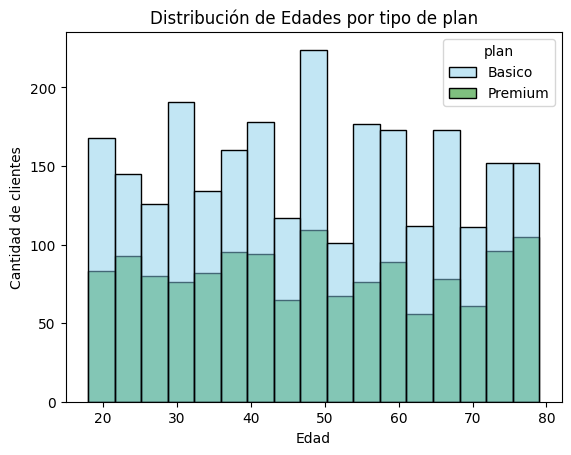

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de Edades por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de clientes')
plt.show()

💡Insights:
- Distribución más equilibrada a partir de los 70+ años, la diferencia entre planes disminuye.
- El plan básico claramente domina en todas las edades.
- Hay un pico notable alrededor de los 50 años para los dos planes, esta es la edad con mayor número de clientes.

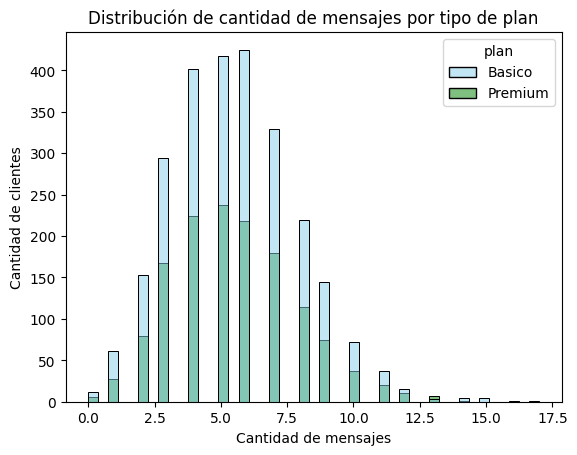

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de cantidad de mensajes por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de clientes')
plt.show()

💡Insights:
- Los datos tienen sesgo hacia la derecha, la distribución tiene una cola larga hacia valores altos de mensajes.
- Hay un pico en 6 mensajes, sin embargo, la mediana de mensajes enviados es 5.
- Los clientes Premium consumen más mensajes en promedio que los Básicos.

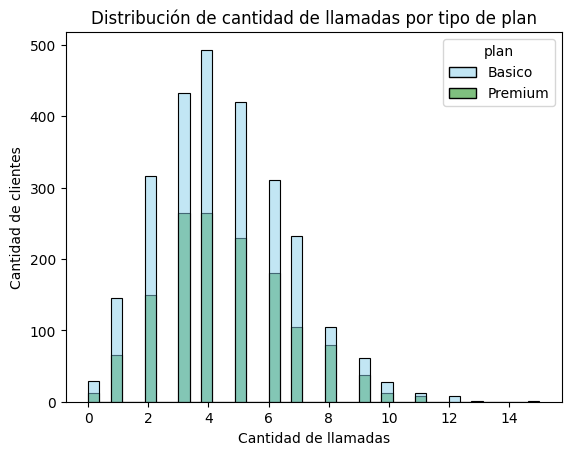

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de cantidad de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de clientes')
plt.show()

💡Insights:
- Distribución normal con cola hacia la derecha.
- La mayoría de los clientes hacen de 3 a 5 llamadas por mes, pocos clientes hacen más de 8 llamadas al mes.
- En los rangos mayores a 6+ llamadas, la proporción de usuarios premium aumenta relativamente.

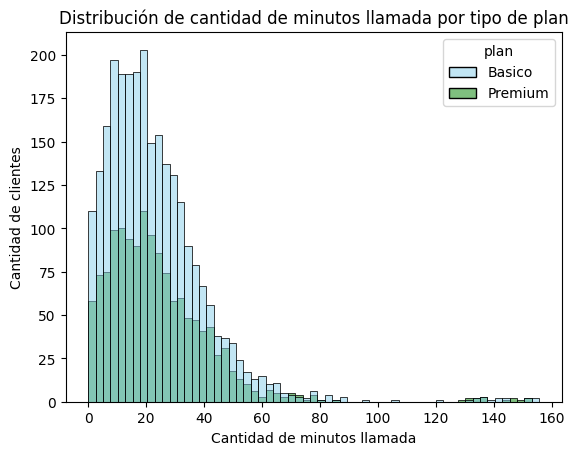

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de cantidad de minutos llamada por tipo de plan')
plt.xlabel('Cantidad de minutos llamada')
plt.ylabel('Cantidad de clientes')
plt.show()

💡Insights:
- El pico principal está entre 10-20 minutos por mes.
- La distribución está sesgada hacia la derecha, algunos usuarios hablan mucho más.
- El plan básico domina en rangos bajos y medios (0 a 40 minutos).
- El plan premium tiene una proporción más notable en rangos medios y altos (+20 minutos).

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.


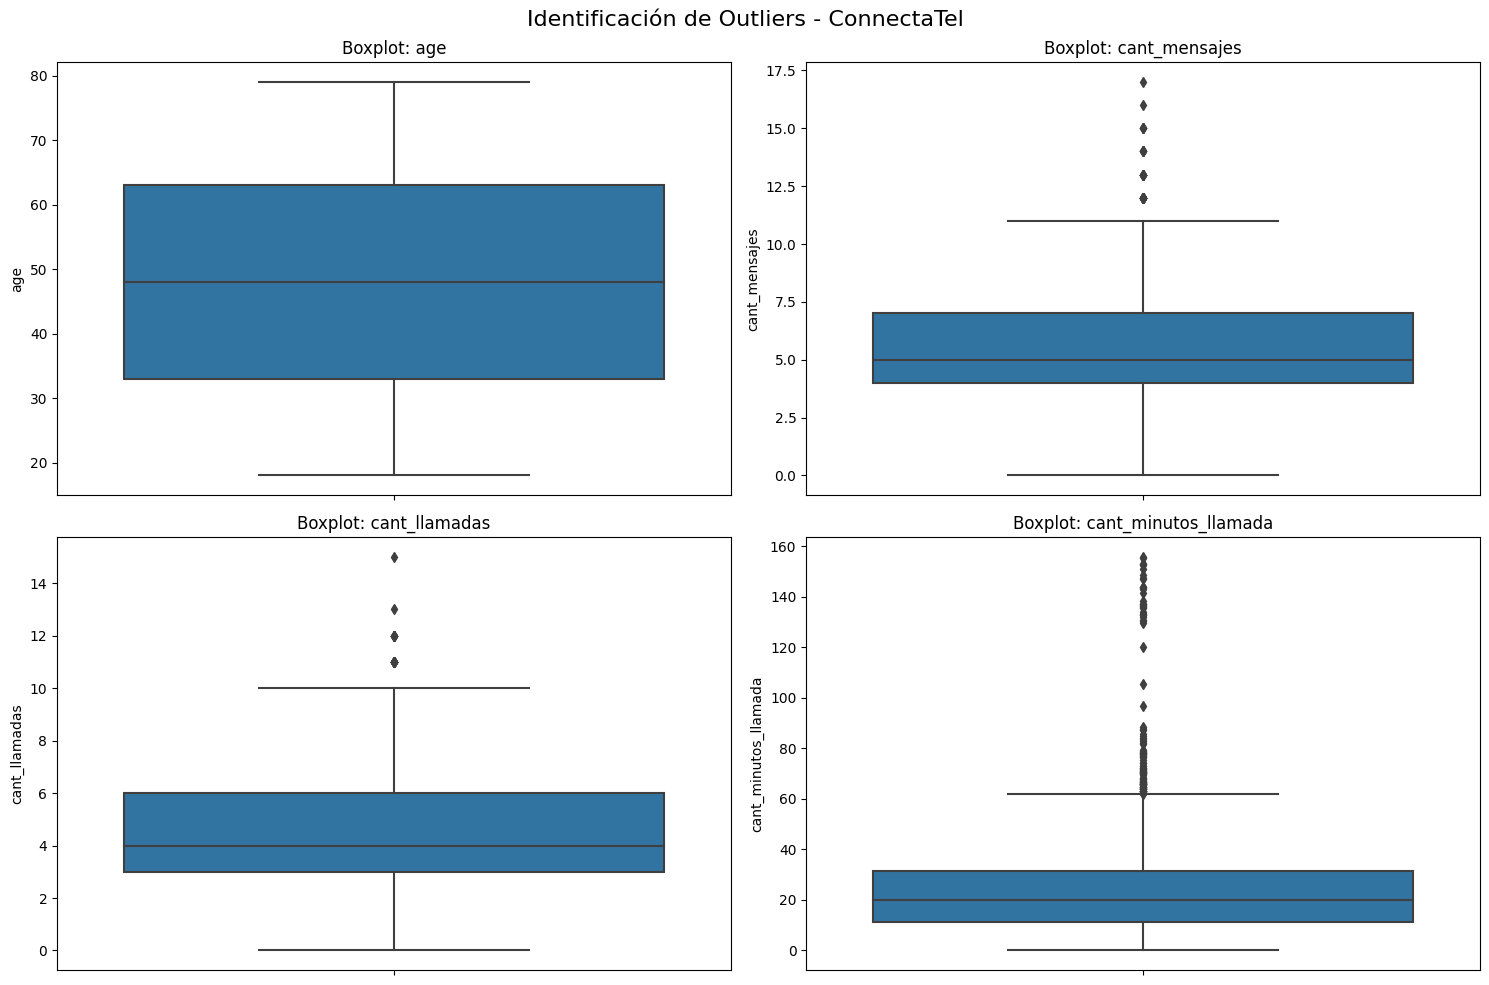

In [ ]:
# Visualizando usando BoxPlot
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Identificación de Outliers - ConnectaTel', fontsize=16)
axes = axes.flatten()

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for i, col in enumerate(columnas_numericas):
    sns.boxplot(data=user_profile, y=col, ax=axes[i])
    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()


💡Insights:
- Age: Tiene distribución simétrica y equilibrada, edades entre los 18 y 79 años, no hay outliers que se alejen de la distribución.
- cant_mensajes: Hay usuarios con comportamiento excepcional, la distribución esta sesgada y asimétrica. Hay valores outliers fuera de los bigotes, cantidad de mensajes entre 11 y 17.
- cant_llamadas: Hay valores outliers reales fuera de la distribución normal, cantidad de llamadas entre 11 y 15. El promedio intercuartil está entre 3 y 6 llamadas.
- cant_minutos_llamada: Esta es la columna con más número de outliers, existen cantidad de minutos llamada entre 60 y 156. La caja muestra que el 50% central de usuarios habla entre 15 y 35 minutos. Los outliers representan usuarios valiosos para ConnectaTel. Usuarios que hablan entre 2 a 6 horas podrían necesitar planes ilimitados.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

limite_superior = Q3 + 1.5* IQR

print(f'Columna: {col}')
print('Primer cuartil: ', Q1)
print('Tercer cuartil: ', Q3)
print('IQR: ', IQR)
print('-' * 30)

user_profile[user_profile[col] > limite_superior][columnas_limites].head()

Columna: cant_minutos_llamada
Primer cuartil:  11.12
Tercer cuartil:  31.415
IQR:  20.295
------------------------------


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
27,28.0,8,7,84.77
85,65.0,6,5,152.36
93,67.0,2,7,71.57
189,63.0,9,4,155.42
198,58.0,8,9,78.77


In [ ]:
# Revisar los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.138285,5.524381,4.478120,23.317054
std,17.691541,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: Decido mantener los outliers, dado que los datos se alejan poco de la distribución y son posibles.
- cant_llamadas: Mantengo los outliers, ya que son valores posibles y se alejan poco del límite superior.
- cant_minutos_llamada: Aunque los valores se alejan bastante de la media, mediana y límite superior, los mantengo dado que son posibles, son valiosos para el análisis y permite identificar clientes valiosos.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.


In [ ]:
# Crear columna grupo_uso
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
]

valores = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(condiciones, valores, default='Alto uso')

In [ ]:
# verificar cambios
user_profile.head()

,user_id,type,cant_llamadas,cant_minutos_llamada,cant_mensajes,length,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,10,3,23.70,7,258.0,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,15,10,33.18,5,226.0,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,7,2,10.74,5,225.0,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,14,3,8.99,11,530.0,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,7,3,8.01,4,229.0,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.


In [ ]:
# Crear columna grupo_edad
condiciones = [(user_profile['age']<30), (user_profile['age']<60)]
etiquetas = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(condiciones, etiquetas, default='Adulto Mayor')

In [ ]:
# verificar cambios
user_profile.head()

,user_id,type,cant_llamadas,cant_minutos_llamada,cant_mensajes,length,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,10,3,23.70,7,258.0,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,15,10,33.18,5,226.0,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,7,2,10.74,5,225.0,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,14,3,8.99,11,530.0,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,7,3,8.01,4,229.0,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.


Uso medio    73.593398
Bajo uso     19.454864
Alto uso      6.951738
Name: grupo_uso, dtype: float64


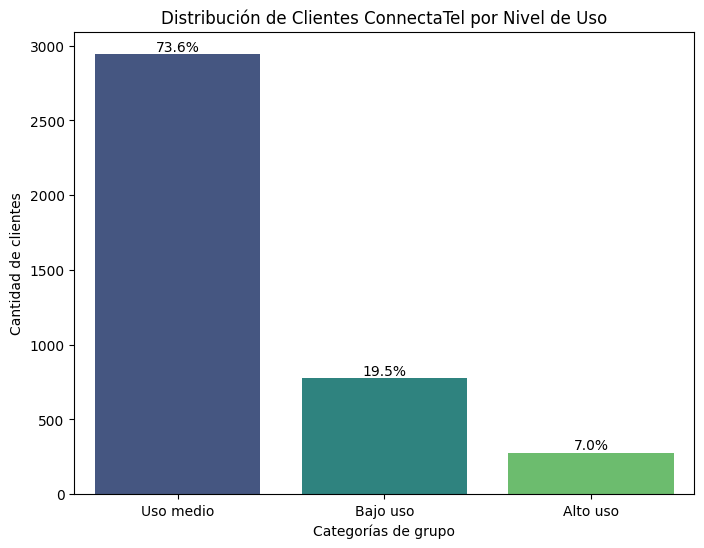

In [ ]:
# Calcular porcentajes
porcentajes = user_profile['grupo_uso'].value_counts(normalize=True) * 100
print(porcentajes)

# Visualización de los segmentos por uso
plt.figure(figsize=(8, 6))

# Ordenar por frecuencia y usar paleta de colores
ax = sns.countplot(data=user_profile,
                   x='grupo_uso',
                   order=user_profile['grupo_uso'].value_counts().index,
                   palette='viridis')

# Agregar porcentajes en las barras
total = len(user_profile)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage,
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.title('Distribución de Clientes ConnectaTel por Nivel de Uso')
plt.xlabel('Categorías de grupo')
plt.ylabel('Cantidad de clientes')

plt.show()

Adulto          50.437609
Adulto Mayor    30.557639
Joven           19.004751
Name: grupo_edad, dtype: float64


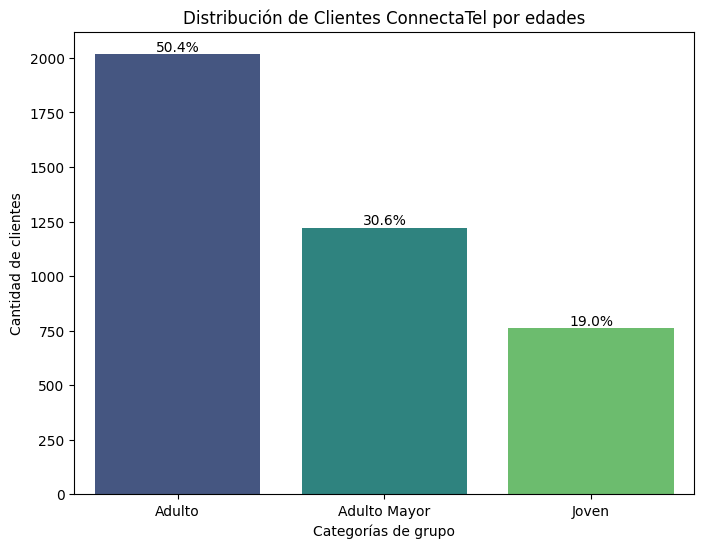

In [ ]:
# Calcular porcentajes
porcentajes = user_profile['grupo_edad'].value_counts(normalize=True) * 100
print(porcentajes)

# Visualización de los segmentos por edad
plt.figure(figsize=(8, 6))

# Ordenar por frecuencia y usar paleta de colores
ax = sns.countplot(data=user_profile,
                   x='grupo_edad',
                   order=user_profile['grupo_edad'].value_counts().index,
                   palette='viridis')

# Agregar porcentajes en las barras
total = len(user_profile)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage,
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.title('Distribución de Clientes ConnectaTel por edades')
plt.xlabel('Categorías de grupo')
plt.ylabel('Cantidad de clientes')

plt.show()

In [ ]:
# Tabla cruzada con números absolutos
tabla_cruzada = pd.crosstab(user_profile['grupo_edad'],
                           user_profile['grupo_uso'])
print("Distribución por números absolutos:")
print(tabla_cruzada)

Distribución por números absolutos:
grupo_uso     Alto uso  Bajo uso  Uso medio
grupo_edad                                 
Adulto             153       364       1500
Adulto Mayor        74       257        891
Joven               51       157        552


In [ ]:
# Tabla cruzada con porcentajes por fila (grupo de edad)
tabla_porcentajes = pd.crosstab(user_profile['grupo_edad'],
                               user_profile['grupo_uso'],
                               normalize='index') * 100
print("\nPorcentajes por grupo de edad:")
print(tabla_porcentajes.round(1))


Porcentajes por grupo de edad:
grupo_uso     Alto uso  Bajo uso  Uso medio
grupo_edad                                 
Adulto             7.6      18.0       74.4
Adulto Mayor       6.1      21.0       72.9
Joven              6.7      20.7       72.6


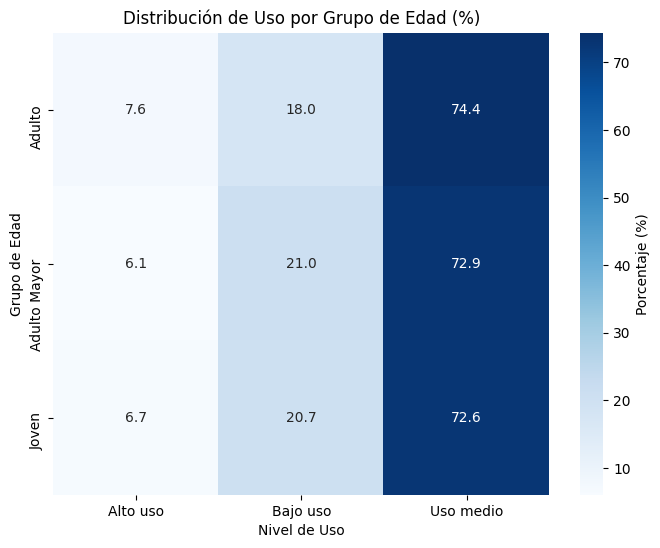

In [ ]:
# Crear un heatmap para visualizar mejor los patrones
plt.figure(figsize=(8, 6))
sns.heatmap(tabla_porcentajes,
            annot=True,
            fmt='.1f',
            cmap='Blues',
            cbar_kws={'label': 'Porcentaje (%)'})
plt.title('Distribución de Uso por Grupo de Edad (%)')
plt.xlabel('Nivel de Uso')
plt.ylabel('Grupo de Edad')
plt.show()

---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- En los datos originales encontré lo siguiente:
En el database user; en la columna `city` 469 valores sentinels con proporción de 0.11725 que se reemplazaron por valores nulos; en la columna `churn_date` 3.534 valores nulos con proporción de 0.88350, la columna se ignoró para el análisis; la columna `age` tenía el valor -999 un outlier que se imputó.
En el database usage; en la columna `date` 50 valores nulos con proporción de 0.00125; en la columna `duration` 22.076 valores nulos con proporción de 0.55190; en la columna `length` 17.896 valores nulos con proporción de 0.44740

🔍 **Segmentos por Edad**

- Los clientes se segmentaron en 3 grupos:
- 'Joven' cuando age < 30
- 'Adulto' cuando age < 60
- 'Adulto Mayor' cuando age >= 60
Todos los grupos de edad muestran una gran preferencia por el uso medio (~72-74%). Este es el patrón más consistente entre los 3 segmentos.
Adultos: Tienen el mayor porcentaje de alto uso (7.6%) son los usuarios más activos.
Jóvenes y Adultos Mayores: Comportamiento muy similar entre sí (6.7% y 6.1% de alto uso respectivamente)

📊 **Segmentos por Nivel de Uso**

El bajo uso representa ~18-21% en todos los grupos, potencial de upselling (venta adicional).
Los adultos son el segmento premium más prometedor.

➡️ Esto sugiere que ...

Los adultos con alto uso, al tener mayor poder adquisitivo, tienen mayor disposición a pagar por servicios premium.
Los adultos con alto uso, Son el segmento más rentable para planes de alta gama.
Los jóvenes valoran más los datos móviles.
Hay oportunidad de crecimiento de crecimiento en todos los grupos.
Posibles implicaciones comerciales críticas: Llamadas internacionales sospechosas, uso masivo repentino, Patrones de bot o uso automatizado.
Oportunidades de negocio:
Alto uso, posibles candidatos para planes premium.
Bajo uso, posible retención de clientes.

💡 **Recomendaciones**

- Crear un plan premium dirigido a adultos porque representan el 74% de usuarios de alto uso y tienen mayor poder adquisitivo. Impacto esperado: Incremento del 15-20% en ingreso promedio por usuario.
- Priorizar campañas de marketing para retención de usuarios y atraer nuevos clientes.
- Personalizar ofertas por segmentación de edades y uso, adultos son los clientes más potenciales.
- Revisar precios, posibles ajustes de precios de planes basados en patrones de uso. Hay oportunidad de venta adicional en usuarios de alto uso.
- Identificar usuarios en riesgo y promover estrategias preventivas por segmento para mantener retención de usuarios.
- Evaluar nuevos productos o servicios, expansión en mercados específicos.
